
# Cross-Language Ad Matching Research — Notebook 01
## RO1: Data Audit, Preprocessing, Leakage-Free Split, and TF-IDF Baseline

**Research task**

Given a Sinhala, English, Singlish, or code-mixed **wanted advertisement**, retrieve the most relevant **offering advertisement**.

**This notebook produces**

- Cleaned dataset
- Script/language-form analysis
- Leakage-free 70/15/15 splits
- Unique offering-ad corpus
- Character n-gram TF-IDF retrieval baseline
- Recall@K, MRR@10, and nDCG@10 results
- CSV files required for the model-training notebook

> Run the cells from top to bottom in Google Colab.



## 1. Install libraries

After running this cell, restart is normally **not** required.


In [ ]:

!pip -q install pandas scikit-learn matplotlib tqdm



## 2. Imports and reproducibility settings


In [ ]:

import os
import re
import json
import random
import hashlib
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

OUTPUT_DIR = Path("/content/research_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)


Output directory: /content/research_outputs



## 3. Load the Damika-7 dataset

The default option downloads the official CSV from Hugging Face.

Set `USE_HUGGINGFACE = False` only when you prefer to upload the CSV manually.


In [ ]:

USE_HUGGINGFACE = True

HF_CSV_URL = (
    "https://huggingface.co/datasets/"
    "Damika-7/sri_Lankan_classified_ads_dataset_for_ad_matching_and_retrieval/"
    "resolve/main/sri_lankan_classified_ads_matching_dataset_v1.csv"
)

if USE_HUGGINGFACE:
    df = pd.read_csv(HF_CSV_URL)
else:
    from google.colab import files
    uploaded = files.upload()
    csv_files = [name for name in uploaded if name.lower().endswith(".csv")]
    if not csv_files:
        raise FileNotFoundError("Please upload a CSV file.")
    df = pd.read_csv(csv_files[0])

print("Dataset shape:", df.shape)
display(df.head(3))


Dataset shape: (54489, 8)


,offering_ad,wanted_ad,category_1,category_2,offering_ad_title,offering_ad_description,wanted_ad_title,wanted_ad_description
0,Ground Floor House for Rent in Colombo 9. Addr...,Looking for a ground floor house for rent in t...,Property,house,Ground Floor House for Rent in Colombo 9. Addr...,Ground Floor House for Rent in Colombo 9. ====...,Looking for a ground floor house for rent in t...,"Budget around 70,000 LKR."
1,නව නිවසක් විකිණීමට මීගොඩ House Sale Meegoda. A...,Looking to buy a house in the Meegoda or Homag...,Property,house,නව නිවසක් විකිණීමට මීගොඩ House Sale Meegoda,"Address: Homagama ,Meegoda ., Bedrooms: 3, Bat...",Looking to buy a house in the Meegoda or Homag...,Around 3 bedrooms would be great. Close to NSB...
2,03 Story House With 08 P Sale At Rawathawatha ...,"Seeking a house around Rawathawatta, Moratuwa....",Property,commercial property,03 Story House With 08 P Sale At Rawathawatha ...,"Property type: Other, Address: Rawathawatha Mo...","Seeking a house around Rawathawatta, Moratuwa",Ideally a two- or three-story house with 4 bed...



## 4. Validate the dataset schema


In [ ]:

EXPECTED_COLUMNS = [
    "offering_ad",
    "wanted_ad",
    "category_1",
    "category_2",
    "offering_ad_title",
    "offering_ad_description",
    "wanted_ad_title",
    "wanted_ad_description",
]

missing_columns = [c for c in EXPECTED_COLUMNS if c not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("Columns are valid.")
print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))

print("Exact duplicate rows:", df.duplicated().sum())
print("Unique offering advertisements:", df["offering_ad"].nunique())
print("Unique wanted advertisements:", df["wanted_ad"].nunique())


Columns are valid.

Missing values:


,missing_count
offering_ad,0
wanted_ad,0
category_1,0
category_2,0
offering_ad_title,0
offering_ad_description,6
wanted_ad_title,0
wanted_ad_description,1


Exact duplicate rows: 0
Unique offering advertisements: 39044
Unique wanted advertisements: 54460



## 5. Text cleaning

The cleaning is intentionally conservative:

- Unicode is normalized using NFC
- Zero-width and non-printing formatting characters are removed
- Repeated whitespace is reduced
- Very long separator sequences are reduced
- Sinhala characters, English characters, numbers, prices, locations, and product models are preserved

We do **not** remove stopwords because short marketplace queries can lose important intent words.


In [ ]:

ZERO_WIDTH_PATTERN = re.compile(r"[\u200B\u200C\u200D\u2060\uFEFF]")
LONG_SEPARATOR_PATTERN = re.compile(r"([=\-_*~.])\1{3,}")
WHITESPACE_PATTERN = re.compile(r"\s+")

def clean_text(value):
    if pd.isna(value):
        return ""
    text = str(value)
    text = unicodedata.normalize("NFC", text)
    text = ZERO_WIDTH_PATTERN.sub("", text)
    text = LONG_SEPARATOR_PATTERN.sub(r"\1\1", text)
    text = WHITESPACE_PATTERN.sub(" ", text)
    return text.strip()

clean_df = df.copy()

TEXT_COLUMNS = [
    "offering_ad",
    "wanted_ad",
    "offering_ad_title",
    "offering_ad_description",
    "wanted_ad_title",
    "wanted_ad_description",
]

for column in TEXT_COLUMNS:
    clean_df[column] = clean_df[column].map(clean_text)

for column in ["category_1", "category_2"]:
    clean_df[column] = clean_df[column].fillna("unknown").astype(str).str.strip()

# Remove rows where either side is empty after cleaning.
before = len(clean_df)
clean_df = clean_df[
    (clean_df["offering_ad"].str.len() > 0)
    & (clean_df["wanted_ad"].str.len() > 0)
].copy()

print("Rows before cleaning:", before)
print("Rows after cleaning:", len(clean_df))
print("Rows removed:", before - len(clean_df))


Rows before cleaning: 54489
Rows after cleaning: 54489
Rows removed: 0



## 6. Create stable IDs and detect writing-script patterns

`script_group` is not a perfect language detector. It is used for error analysis:

- `latin_only` can contain English or Romanized Sinhala/Singlish
- `sinhala_only`
- `sinhala_latin`
- Tamil-related groups
- `other`


In [ ]:

def stable_hash(text):
    return hashlib.sha1(text.encode("utf-8")).hexdigest()[:16]

def detect_script_group(text):
    text = str(text)
    has_sinhala = any("\u0D80" <= char <= "\u0DFF" for char in text)
    has_tamil = any("\u0B80" <= char <= "\u0BFF" for char in text)
    has_latin = bool(re.search(r"[A-Za-z]", text))

    if has_sinhala and has_latin:
        return "sinhala_latin"
    if has_tamil and has_latin:
        return "tamil_latin"
    if has_sinhala:
        return "sinhala_only"
    if has_tamil:
        return "tamil_only"
    if has_latin:
        return "latin_only"
    return "other"

clean_df["offering_id"] = clean_df["offering_ad"].map(stable_hash)
clean_df["wanted_id"] = clean_df["wanted_ad"].map(stable_hash)
clean_df["wanted_script_group"] = clean_df["wanted_ad"].map(detect_script_group)
clean_df["offering_script_group"] = clean_df["offering_ad"].map(detect_script_group)

clean_df["offering_word_count"] = clean_df["offering_ad"].str.split().str.len()
clean_df["wanted_word_count"] = clean_df["wanted_ad"].str.split().str.len()

display(clean_df.head(3))


,offering_ad,wanted_ad,category_1,category_2,offering_ad_title,offering_ad_description,wanted_ad_title,wanted_ad_description,offering_id,wanted_id,wanted_script_group,offering_script_group,offering_word_count,wanted_word_count
0,Ground Floor House for Rent in Colombo 9. Addr...,Looking for a ground floor house for rent in t...,Property,house,Ground Floor House for Rent in Colombo 9. Addr...,Ground Floor House for Rent in Colombo 9. ==. ...,Looking for a ground floor house for rent in t...,"Budget around 70,000 LKR.",e9ccc97c6f427c67,ac0f3c4b5d06c8cb,latin_only,latin_only,99,33
1,නව නිවසක් විකිණීමට මීගොඩ House Sale Meegoda. A...,Looking to buy a house in the Meegoda or Homag...,Property,house,නව නිවසක් විකිණීමට මීගොඩ House Sale Meegoda,"Address: Homagama ,Meegoda ., Bedrooms: 3, Bat...",Looking to buy a house in the Meegoda or Homag...,Around 3 bedrooms would be great. Close to NSB...,bfc359189ac7369d,eb7e439af3274de5,latin_only,sinhala_latin,163,32
2,03 Story House With 08 P Sale At Rawathawatha ...,"Seeking a house around Rawathawatta, Moratuwa....",Property,commercial property,03 Story House With 08 P Sale At Rawathawatha ...,"Property type: Other, Address: Rawathawatha Mo...","Seeking a house around Rawathawatta, Moratuwa",Ideally a two- or three-story house with 4 bed...,2d9b7a7528332128,13a1bea5b7f01b1e,latin_only,latin_only,101,32



## 7. Exploratory Data Analysis


In [ ]:

category_1_summary = (
    clean_df["category_1"]
    .value_counts()
    .rename_axis("category_1")
    .reset_index(name="rows")
)
category_1_summary["percentage"] = (
    category_1_summary["rows"] / len(clean_df) * 100
).round(2)

category_2_summary = (
    clean_df["category_2"]
    .value_counts()
    .rename_axis("category_2")
    .reset_index(name="rows")
)
category_2_summary["percentage"] = (
    category_2_summary["rows"] / len(clean_df) * 100
).round(2)

script_summary = (
    clean_df["wanted_script_group"]
    .value_counts()
    .rename_axis("script_group")
    .reset_index(name="rows")
)
script_summary["percentage"] = (
    script_summary["rows"] / len(clean_df) * 100
).round(2)

print("Main-category distribution")
display(category_1_summary)

print("Subcategory distribution")
display(category_2_summary)

print("Wanted-ad script distribution")
display(script_summary)

print("Text-length summary")
display(
    clean_df[
        ["offering_word_count", "wanted_word_count"]
    ].describe(percentiles=[0.5, 0.9, 0.95, 0.99])
)


Main-category distribution


,category_1,rows,percentage
0,Electronics,20254,37.17
1,Vehicle,18115,33.25
2,Property,16120,29.58


Subcategory distribution


,category_2,rows,percentage
0,car,4299,7.89
1,van,4188,7.69
2,house,3902,7.16
3,land,3898,7.15
4,commercial property,3873,7.11
5,lorry_truck,3732,6.85
6,apartment,3334,6.12
7,Electronic Home Appliances,3134,5.75
8,Mobile Phones & Tablets,2643,4.85
9,three-wheeler,2410,4.42


Wanted-ad script distribution


,script_group,rows,percentage
0,latin_only,29486,54.11
1,sinhala_latin,19331,35.48
2,sinhala_only,5660,10.39
3,tamil_only,8,0.01
4,tamil_latin,4,0.01


Text-length summary


,offering_word_count,wanted_word_count
count,54489.000000,54489.000000
mean,93.517811,19.539558
std,93.937816,5.870168
min,2.000000,3.000000
50%,64.000000,19.000000
90%,198.000000,27.000000
95%,269.000000,30.000000
99%,495.120000,35.000000
max,855.000000,80.000000


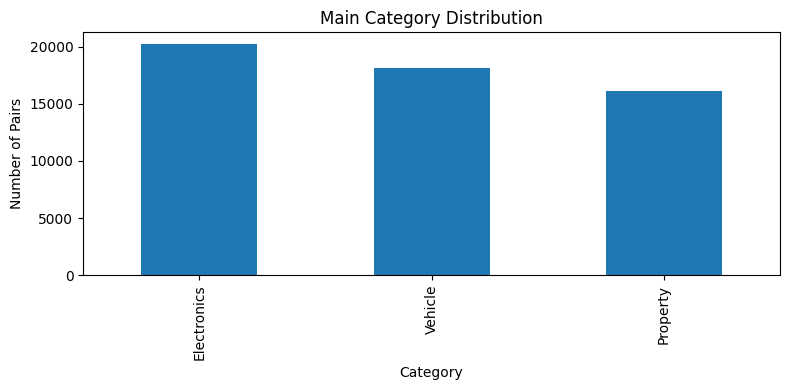

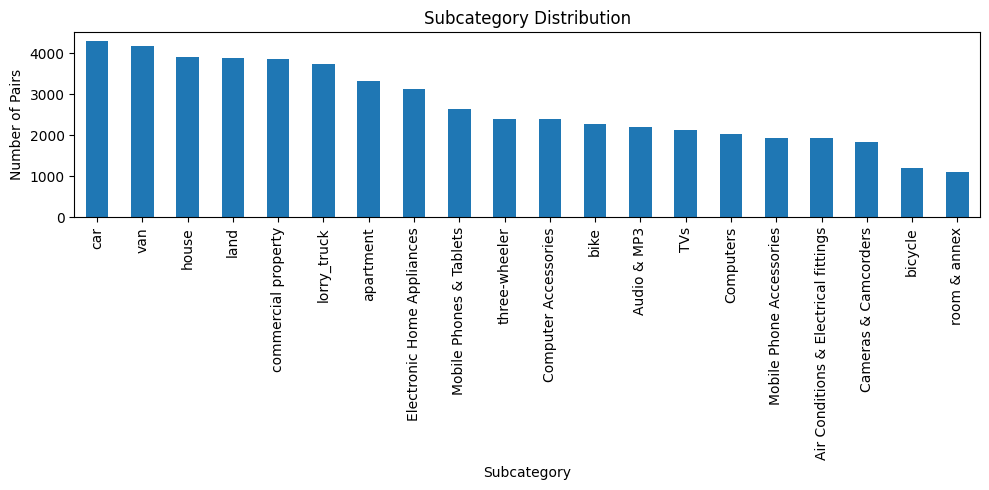

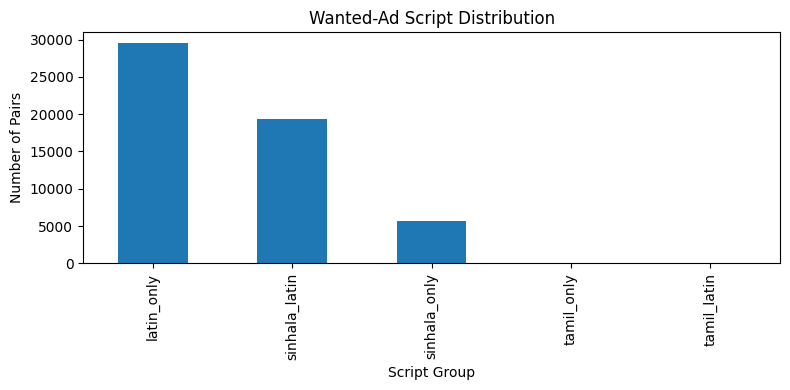

In [ ]:

plt.figure(figsize=(8, 4))
clean_df["category_1"].value_counts().plot(kind="bar")
plt.title("Main Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Pairs")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "category_1_distribution.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
clean_df["category_2"].value_counts().plot(kind="bar")
plt.title("Subcategory Distribution")
plt.xlabel("Subcategory")
plt.ylabel("Number of Pairs")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "category_2_distribution.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 4))
clean_df["wanted_script_group"].value_counts().plot(kind="bar")
plt.title("Wanted-Ad Script Distribution")
plt.xlabel("Script Group")
plt.ylabel("Number of Pairs")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "wanted_script_distribution.png", dpi=200)
plt.show()



## 8. Inspect repeated offering advertisements

A repeated offering ad can have multiple wanted queries. All rows belonging to the same `offering_id` must remain in the same split.


In [ ]:

offering_frequency = clean_df["offering_id"].value_counts()

print("Offering-frequency distribution")
display(
    offering_frequency.value_counts()
    .sort_index()
    .rename_axis("queries_per_offering")
    .reset_index(name="number_of_offerings")
)

print("Maximum queries for one offering:", offering_frequency.max())


Offering-frequency distribution


,queries_per_offering,number_of_offerings
0,1,23571
1,2,15438
2,3,4
3,4,3
4,5,1
5,6,1
6,7,1


Maximum queries for one offering: 7



## 9. Create a leakage-free 70/15/15 split

The split is performed at the **unique offering-ad level** and stratified by subcategory.

This guarantees that the same offering advertisement cannot occur in both training and testing.


In [ ]:

offering_groups = (
    clean_df[
        ["offering_id", "offering_ad", "category_1", "category_2"]
    ]
    .drop_duplicates("offering_id")
    .reset_index(drop=True)
)

# Check that each offering maps to only one subcategory.
subcategory_counts = clean_df.groupby("offering_id")["category_2"].nunique()
if subcategory_counts.max() != 1:
    raise ValueError("At least one offering maps to multiple subcategories.")

train_groups, temp_groups = train_test_split(
    offering_groups,
    test_size=0.30,
    random_state=SEED,
    stratify=offering_groups["category_2"],
)

val_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_groups["category_2"],
)

split_map = {}
split_map.update({offering_id: "train" for offering_id in train_groups["offering_id"]})
split_map.update({offering_id: "validation" for offering_id in val_groups["offering_id"]})
split_map.update({offering_id: "test" for offering_id in test_groups["offering_id"]})

clean_df["split"] = clean_df["offering_id"].map(split_map)

print(clean_df["split"].value_counts())
print("\nPair-level percentages")
display(
    (clean_df["split"].value_counts(normalize=True) * 100)
    .round(2)
    .rename("percentage")
    .to_frame()
)

print("\nUnique-offering percentages")
display(
    (offering_groups["offering_id"].map(split_map).value_counts(normalize=True) * 100)
    .round(2)
    .rename("percentage")
    .to_frame()
)


split
train         38180
validation     8160
test           8149
Name: count, dtype: int64

Pair-level percentages


,percentage
split,
train,70.07
validation,14.98
test,14.96



Unique-offering percentages


,percentage
offering_id,
train,70.0
test,15.0
validation,15.0



## 10. Verify that there is no offering-ad leakage


In [ ]:

train_ids = set(clean_df.loc[clean_df["split"] == "train", "offering_id"])
val_ids = set(clean_df.loc[clean_df["split"] == "validation", "offering_id"])
test_ids = set(clean_df.loc[clean_df["split"] == "test", "offering_id"])

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

print("Leakage check passed.")
print("Train unique offerings:", len(train_ids))
print("Validation unique offerings:", len(val_ids))
print("Test unique offerings:", len(test_ids))


Leakage check passed.
Train unique offerings: 27313
Validation unique offerings: 5853
Test unique offerings: 5853



## 11. Build the retrieval corpus

Each unique offering ad is indexed only once.


In [ ]:

corpus_df = (
    clean_df[
        [
            "offering_id",
            "offering_ad",
            "category_1",
            "category_2",
            "offering_script_group",
        ]
    ]
    .drop_duplicates("offering_id")
    .reset_index(drop=True)
)

corpus_df["corpus_index"] = np.arange(len(corpus_df))
offering_id_to_index = dict(
    zip(corpus_df["offering_id"], corpus_df["corpus_index"])
)

clean_df["target_corpus_index"] = clean_df["offering_id"].map(offering_id_to_index)

print("Corpus size:", len(corpus_df))
display(corpus_df.head(3))


Corpus size: 39019


,offering_id,offering_ad,category_1,category_2,offering_script_group,corpus_index
0,e9ccc97c6f427c67,Ground Floor House for Rent in Colombo 9. Addr...,Property,house,latin_only,0
1,bfc359189ac7369d,නව නිවසක් විකිණීමට මීගොඩ House Sale Meegoda. A...,Property,house,sinhala_latin,1
2,2d9b7a7528332128,03 Story House With 08 P Sale At Rawathawatha ...,Property,commercial property,latin_only,2



## 12. Save RO1 outputs


In [ ]:

clean_df.to_csv(OUTPUT_DIR / "clean_pairs_with_splits.csv", index=False)
corpus_df.to_csv(OUTPUT_DIR / "offering_corpus.csv", index=False)

for split_name in ["train", "validation", "test"]:
    clean_df[clean_df["split"] == split_name].to_csv(
        OUTPUT_DIR / f"{split_name}_pairs.csv",
        index=False,
    )

category_1_summary.to_csv(
    OUTPUT_DIR / "category_1_summary.csv",
    index=False,
)
category_2_summary.to_csv(
    OUTPUT_DIR / "category_2_summary.csv",
    index=False,
)
script_summary.to_csv(
    OUTPUT_DIR / "wanted_script_summary.csv",
    index=False,
)

print("Saved files:")
for file_path in sorted(OUTPUT_DIR.iterdir()):
    print("-", file_path.name)


Saved files:
- category_1_distribution.png
- category_1_summary.csv
- category_2_distribution.png
- category_2_summary.csv
- clean_pairs_with_splits.csv
- offering_corpus.csv
- test_pairs.csv
- train_pairs.csv
- validation_pairs.csv
- wanted_script_distribution.png
- wanted_script_summary.csv



# TF-IDF Retrieval Baseline

This is the first benchmark model.

Character n-grams are useful for:

- Misspellings
- Product model numbers
- Romanized Sinhala variations
- Mixed Sinhala-English text
- Partial word overlap


In [ ]:

vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_features=120_000,
    sublinear_tf=True,
    dtype=np.float32,
)

print("Fitting TF-IDF on the offering corpus...")
corpus_matrix = vectorizer.fit_transform(corpus_df["offering_ad"])

print("Corpus matrix shape:", corpus_matrix.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))


Fitting TF-IDF on the offering corpus...
Corpus matrix shape: (39019, 120000)
Vocabulary size: 120000


In [ ]:

TOP_K = 10

retriever = NearestNeighbors(
    n_neighbors=TOP_K,
    metric="cosine",
    algorithm="brute",
    n_jobs=-1,
)
retriever.fit(corpus_matrix)

test_df = clean_df[clean_df["split"] == "test"].reset_index(drop=True)
print("Number of test queries:", len(test_df))


Number of test queries: 8149



## 13. Retrieve the top 10 results in batches


In [ ]:

def retrieve_in_batches(texts, batch_size=512):
    all_indices = []
    all_distances = []

    for start in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts.iloc[start : start + batch_size]
        query_matrix = vectorizer.transform(batch_texts)
        distances, indices = retriever.kneighbors(
            query_matrix,
            n_neighbors=TOP_K,
            return_distance=True,
        )
        all_indices.append(indices)
        all_distances.append(distances)

    return np.vstack(all_distances), np.vstack(all_indices)

test_distances, test_indices = retrieve_in_batches(test_df["wanted_ad"])
print("Retrieved result shape:", test_indices.shape)


  0%|          | 0/16 [00:00<?, ?it/s]

Retrieved result shape: (8149, 10)



## 14. Calculate retrieval metrics

Each query has one known relevant offering ad.

- **Recall@K**: Was the correct ad present within the first K results?
- **MRR@10**: Rewards placing the correct ad near the top
- **nDCG@10**: Position-sensitive ranking quality


In [ ]:

def calculate_ranks(retrieved_indices, target_indices):
    ranks = []
    for retrieved, target in zip(retrieved_indices, target_indices):
        positions = np.where(retrieved == target)[0]
        rank = int(positions[0] + 1) if len(positions) else None
        ranks.append(rank)
    return ranks

def retrieval_metrics(ranks):
    metrics = {}
    for k in [1, 5, 10]:
        metrics[f"Recall@{k}"] = np.mean(
            [rank is not None and rank <= k for rank in ranks]
        )

    metrics["MRR@10"] = np.mean(
        [1.0 / rank if rank is not None and rank <= 10 else 0.0 for rank in ranks]
    )

    metrics["nDCG@10"] = np.mean(
        [
            1.0 / np.log2(rank + 1)
            if rank is not None and rank <= 10
            else 0.0
            for rank in ranks
        ]
    )
    return metrics

test_ranks = calculate_ranks(
    test_indices,
    test_df["target_corpus_index"].to_numpy(),
)

overall_metrics = retrieval_metrics(test_ranks)
overall_metrics_df = pd.DataFrame(
    [overall_metrics],
    index=["TF-IDF char n-gram"],
)

display(overall_metrics_df.round(4))
overall_metrics_df.to_csv(
    OUTPUT_DIR / "tfidf_overall_metrics.csv"
)


,Recall@1,Recall@5,Recall@10,MRR@10,nDCG@10
TF-IDF char n-gram,0.2524,0.416,0.4883,0.3229,0.3623



## 15. Evaluate by main category and script group

This prevents a strong English score from hiding weak Sinhala or mixed-script performance.


In [ ]:

evaluation_df = test_df[
    [
        "wanted_id",
        "wanted_ad",
        "offering_id",
        "category_1",
        "category_2",
        "wanted_script_group",
    ]
].copy()
evaluation_df["rank_at_10"] = test_ranks

def grouped_metric_table(data, group_column):
    rows = []
    for group_value, group_data in data.groupby(group_column):
        metrics = retrieval_metrics(group_data["rank_at_10"].tolist())
        rows.append(
            {
                group_column: group_value,
                "query_count": len(group_data),
                **metrics,
            }
        )
    return pd.DataFrame(rows).sort_values(
        "query_count",
        ascending=False,
    )

category_metrics = grouped_metric_table(
    evaluation_df,
    "category_1",
)
subcategory_metrics = grouped_metric_table(
    evaluation_df,
    "category_2",
)
script_metrics = grouped_metric_table(
    evaluation_df,
    "wanted_script_group",
)

print("Main-category metrics")
display(category_metrics.round(4))

print("Subcategory metrics")
display(subcategory_metrics.round(4))

print("Script-group metrics")
display(script_metrics.round(4))

category_metrics.to_csv(
    OUTPUT_DIR / "tfidf_category_metrics.csv",
    index=False,
)
subcategory_metrics.to_csv(
    OUTPUT_DIR / "tfidf_subcategory_metrics.csv",
    index=False,
)
script_metrics.to_csv(
    OUTPUT_DIR / "tfidf_script_metrics.csv",
    index=False,
)
evaluation_df.to_csv(
    OUTPUT_DIR / "tfidf_test_query_results.csv",
    index=False,
)


Main-category metrics


,category_1,query_count,Recall@1,Recall@5,Recall@10,MRR@10,nDCG@10
0,Electronics,3015,0.1977,0.3562,0.4375,0.2678,0.3080
2,Vehicle,2707,0.3373,0.5253,0.5962,0.4164,0.4594
1,Property,2427,0.2258,0.3684,0.4310,0.2872,0.3214


Subcategory metrics


,category_2,query_count,Recall@1,Recall@5,Recall@10,MRR@10,nDCG@10
12,car,650,0.4046,0.6400,0.7185,0.4990,0.5515
19,van,624,0.2869,0.4904,0.5689,0.3730,0.4199
15,land,591,0.1980,0.3519,0.4264,0.2640,0.3024
14,house,586,0.2304,0.3447,0.3993,0.2820,0.3098
13,commercial property,582,0.2577,0.4158,0.4656,0.3245,0.3585
16,lorry_truck,560,0.3232,0.5143,0.6054,0.4058,0.4531
9,apartment,503,0.1571,0.3121,0.3877,0.2221,0.2613
5,Electronic Home Appliances,471,0.2144,0.3843,0.4883,0.2911,0.3375
7,Mobile Phones & Tablets,381,0.1365,0.2598,0.3307,0.1943,0.2266
18,three-wheeler,368,0.2201,0.3397,0.4022,0.2746,0.3050


Script-group metrics


,wanted_script_group,query_count,Recall@1,Recall@5,Recall@10,MRR@10,nDCG@10
0,latin_only,4380,0.3080,0.4792,0.5493,0.3819,0.4219
1,sinhala_latin,2890,0.2194,0.3997,0.4872,0.2967,0.3418
2,sinhala_only,877,0.0844,0.1539,0.1870,0.1151,0.1322
3,tamil_only,2,0.0000,0.5000,0.5000,0.2500,0.3155



## 16. Inspect successful and failed examples


In [ ]:

def show_retrieval_example(query_position, number_of_results=5):
    row = test_df.iloc[query_position]
    print("QUERY")
    print(row["wanted_ad"])
    print("\nTRUE OFFERING")
    print(
        corpus_df.iloc[row["target_corpus_index"]]["offering_ad"][:1000]
    )

    print("\nTOP RESULTS")
    for rank, corpus_index in enumerate(
        test_indices[query_position][:number_of_results],
        start=1,
    ):
        candidate = corpus_df.iloc[corpus_index]
        similarity = 1.0 - test_distances[query_position][rank - 1]
        marker = " <-- CORRECT" if corpus_index == row["target_corpus_index"] else ""
        print(
            f"\nRank {rank} | Similarity {similarity:.4f} | "
            f"{candidate['category_1']} / {candidate['category_2']}{marker}"
        )
        print(candidate["offering_ad"][:500])

failed_positions = [
    index
    for index, rank in enumerate(test_ranks)
    if rank is None
]

successful_positions = [
    index
    for index, rank in enumerate(test_ranks)
    if rank == 1
]

print("Successful Rank-1 examples:", len(successful_positions))
print("Failures outside Top-10:", len(failed_positions))


Successful Rank-1 examples: 2057
Failures outside Top-10: 4170


In [ ]:

# Change the number to inspect another example.
if successful_positions:
    show_retrieval_example(successful_positions[0])


QUERY
Interested in purchasing a small hotel or villa in Mirissa, preferably near the beach. Looking for something with a liquor license.

TRUE OFFERING
Mirissa Villa for sale. Property type: Hotel, Size: 2,000 sqft. Serenity Hostel - Mirissa. 25perch. 4 room. FL 7 Liquor Licence. 200 meters to mirissa beach strip. 50meters to Mirissa Town

TOP RESULTS

Rank 1 | Similarity 0.3872 | Property / commercial property <-- CORRECT
Mirissa Villa for sale. Property type: Hotel, Size: 2,000 sqft. Serenity Hostel - Mirissa. 25perch. 4 room. FL 7 Liquor Licence. 200 meters to mirissa beach strip. 50meters to Mirissa Town

Rank 2 | Similarity 0.2779 | Property / commercial property
Villa for Sale mirissa Near. Property type: Hotel, Address: mirissa near, Size: 6,000 sqft. 27 perches with garden balcony hot water ac kitchen 7 rooms with bathrooms

Rank 3 | Similarity 0.2432 | Property / commercial property
(ARN76) Beachfront Villas for Sale Dickwella. Property type: Hotel, Address: Dickwella Bay., S

In [ ]:

# Change the number to inspect another failed example.
if failed_positions:
    show_retrieval_example(failed_positions[0])


QUERY
Looking for a block of land around Homagama, preferably in a gated community with amenities like a gym and swimming pool.

TRUE OFFERING
land for sale in homagama. Address: Homagama , Land type: Residential, Land size: 6.0 perches. හෝමාගම නගරයට මිනිත්තු 10 කින් සහ තවත් බොහෝ නාගරික අවශ්යතා සඳහා මිනිත්තු කිහිපයකින් සශ්රීක හරිතකරණයේ පරිපූර්ණ සම්මිශ්රණයක් ලබා ගන්න. ඇතුළු පහසුකම් සපයා ඇති ඔබේම නිවසේ සිටම සතා සිවුපාවා පිළිබඳ අද්විතීය දසුනක් භුක්ති විඳින්න,. පැය 24 ආරක්ෂාව. දොරටු සහිත ප්රජාව. ව්යායාම ශාලාව. Jogging Track. පිහිනුම් තටාකය සහ තවත් බොහෝ දේ

TOP RESULTS

Rank 1 | Similarity 0.2405 | Property / house
House for Rent in Kelaniya. Address: Dalugama ,Kelaniya , Beds: 3, Baths: 3, House size: 2,000.0 sqft, Land size: 6.0 perches. Property Number - 351. Two story. Bedroom - 03. Bathroom -03. Living. Dining. Kitchen. Parking. Unfurnished. Gated community. Swimming Pool. Gym

Rank 2 | Similarity 0.2325 | Property / house
Brand New Town House in Gated Community for Sale Kottawa. Bedro


## 17. Download all outputs


In [ ]:

import shutil
from google.colab import files

zip_path = shutil.make_archive(
    "/content/RO1_outputs",
    "zip",
    OUTPUT_DIR,
)
print("Created:", zip_path)
files.download(zip_path)


Created: /content/RO1_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# Report-ready methodology statement

You may adapt the following paragraph for the thesis:

> The dataset was normalized using Unicode NFC normalization, whitespace standardization, and conservative removal of non-printing characters while preserving Sinhala script, Latin script, numerical attributes, product model identifiers, prices, and location information. Stable document identifiers were generated from normalized offering texts. Because a single offering advertisement could be paired with multiple wanted queries, splitting individual rows would introduce document leakage. Therefore, a group-level stratified split was performed using unique offering-ad identifiers, allocating 70% of offerings to training, 15% to validation, and 15% to testing while preserving subcategory distributions. Retrieval evaluation used wanted advertisements as queries and the unique offering advertisements as the searchable corpus. A character n-gram TF-IDF model was implemented as the lexical baseline and evaluated using Recall@1, Recall@5, Recall@10, MRR@10, and nDCG@10, including category-wise and script-wise analyses.
